#Parameters and Paths

In [ ]:
import os

# ======== Parameters ========
DATA_PATH = "/content/sample_data/BMTCH.xlsx"
SHEET = None  # None -> default sheet
TARGET = "acute_GvHD_II_III_IV"



TEST_SIZE = 0.15
RANDOM_STATE = 16

# Tuner hyperparameters (reduced due to limited data)
MAX_TRIALS = 10
EPOCHS = 1000
BATCH_SIZE = 16

# Output directories
OUT_DIR = "outputs_nn_base"
TUNER_DIR = "tuner_results"
PROJECT_NAME = "modelo_base_gvhd"
META_PATH = os.path.join(OUT_DIR, "meta.json")
print("Meta will be saved to:", META_PATH)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(TUNER_DIR, exist_ok=True)

# Artifact paths
MODEL_BASE_FULL_PATH = os.path.join(OUT_DIR, "base_model_full_data.keras")
PREPROCESSOR_PATH = os.path.join(OUT_DIR, "preprocessor.joblib")

print("Output folder:", OUT_DIR)


Meta will be saved to: outputs_nn_base/meta.json
Output folder: outputs_nn_base


#Libraries and reproducibility

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00


In [ ]:
# ======== Libraries ========
import random
import json
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers
from tensorflow.keras.callbacks import Callback

import keras_tuner as kt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score

import joblib

# Optional metrics debugging
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, classification_report
)

# ======== Semillas ========
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = "0"

random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


#Data loading and filters

In [ ]:
# ======== Data loading ========
if SHEET is None:
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH, sheet_name=SHEET)

assert TARGET in df.columns, f"Columna objective '{TARGET}' not found"

print("Shape original:", df.shape)



# Seleccionamos columnas (ajusta si quieres agregar/quitar)
cols = ['agegp','risk_group','stem_cell_source','HLA_mismatch', TARGET]
df = df.loc[:, cols]
cleanup_nums = {"acute_GvHD_II_III_IV": {"yes":1, "no":0}}
df =df.replace(cleanup_nums)
df.acute_GvHD_II_III_IV=df.acute_GvHD_II_III_IV.astype('int')
# No imputation: we drop rows with NaN
df = df.dropna()
print("Shape after filtering + dropna:", df.shape)
print("Target distribution:\n", df[TARGET].value_counts())

df.head()


Shape original: (187, 39)
Shape after filtering + dropna: (187, 5)
Target distribution:
 acute_GvHD_II_III_IV
1    112
0     75
Name: count, dtype: int64


/tmp/ipykernel_2868/1172951913.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df =df.replace(cleanup_nums)


,agegp,risk_group,stem_cell_source,HLA_mismatch,acute_GvHD_II_III_IV
0,2,high,peripheral_blood,matched,1
1,2,low,bone_marrow,matched,1
2,2,low,bone_marrow,matched,1
3,3,low,bone_marrow,matched,1
4,1,high,peripheral_blood,matched,0


#Train/val split and preprocessor

In [ ]:
# ======== Separar X, y ========
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET]).copy()

# Detect numeric vs categorical
#num_cols = X.select_dtypes(include=["number", "float", "int", "int64", "float64"]).columns.tolist()
cat_cols=df.loc[:,['risk_group','agegp','stem_cell_source','HLA_mismatch']].columns.to_list()

#print(f"Numerical ({len(num_cols)}):", num_cols)
print(f"Categorical ({len(cat_cols)}):", cat_cols)

# Split train / valid
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train_raw.shape, "| Val:", X_val_raw.shape)

# ======== Preprocessor para tuning (solo en train) ========
pre_tune = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         cat_cols),

    ]
)

X_train = pre_tune.fit_transform(X_train_raw)
X_val   = pre_tune.transform(X_val_raw)

print("X_train shape (tuning):", X_train.shape, "| X_val shape:", X_val.shape)


Categorical (4): ['risk_group', 'agegp', 'stem_cell_source', 'HLA_mismatch']
Train: (158, 4) | Val: (29, 4)
X_train shape (tuning): (158, 9) | X_val shape: (29, 9)


#Validation F1 callback

In [ ]:
# ======== Callback: ValF1Callback ========
class ValF1Callback(Callback):
    def __init__(self, val_data, average='binary', threshold=0.5,
                 save_best_path=None, verbose=False):
        super().__init__()
        self.X_val, self.y_val = val_data
        self.average = average
        self.threshold = threshold
        self.save_best_path = save_best_path
        self.best = -1.0
        self.verbose = verbose

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_prob = self.model.predict(self.X_val, verbose=0).ravel()
        y_hat = (y_prob >= self.threshold).astype(int)
        val_f1 = f1_score(self.y_val, y_hat, average=self.average)
        logs["val_f1"] = float(val_f1)

        if val_f1 > self.best:
            self.best = val_f1
            if self.save_best_path:
                self.model.save(self.save_best_path, overwrite=True)

        if self.verbose:
            print(f"\nEpoch {epoch+1}: val_f1={val_f1:.4f} (best={self.best:.4f})")


#Neural network

In [ ]:
# ======== Base model con capa 'encoder' reutilizable ========
def build_model(hp: kt.HyperParameters):
    """
    Small base model with an explicit 'encoder' layer for later reuse.
    Pensado para ~9 features y ~126 ejemplos.
    """
    input_dim = X_train.shape[1]

    inputs = layers.Input(shape=(input_dim,), name="features")

    # 1) Capas previas (opcionales: 0 o 1)
    n_pre_layers = hp.Int("n_pre_layers", min_value=0, max_value=1, step=1)
    pre_units = hp.Int("pre_units", min_value=8, max_value=32, step=8)

    l2_reg = hp.Choice("l2", values=[0.0, 1e-4, 1e-3])
    dr_pre = hp.Choice("dropout_pre", values=[0.0, 0.2])

    x = inputs
    for i in range(n_pre_layers):
        x = layers.Dense(
            pre_units,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None,
            name=f"pre_dense_{i+1}"
        )(x)
        if dr_pre > 0:
            x = layers.Dropout(dr_pre, name=f"pre_dropout_{i+1}")(x)

    # 2) Capa ENCODER (bloque reutilizable)
    encoder_units = hp.Int("encoder_units", min_value=4, max_value=16, step=4)
    dr_enc = hp.Choice("dropout_enc", values=[0.0, 0.2])

    encoder = layers.Dense(
        encoder_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None,
        name="encoder"   # 👈 nombre clave para reutilizar luego
    )(x)

    if dr_enc > 0:
        z = layers.Dropout(dr_enc, name="encoder_dropout")(encoder)
    else:
        z = encoder

    # 3) Output layer (head for the current task)
    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="gvhd_head"
    )(z)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="base_gvhd_model"
    )

    # 4) Compilation
    lr = hp.Choice("lr", values=[1e-3, 5e-4])
    opt = optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
        # val_f1 lo calculamos con ValF1Callback
    )

    return model


#Search with Keras Tuner (RandomSearch, objective val_f1)

In [ ]:
# ======== Tuner: RandomSearch over build_model ========
val_f1_cb_tuner = ValF1Callback(
    val_data=(X_val, y_val),
    average='binary',
    threshold=0.5,
    save_best_path=None,  # el tuner se queda con el mejor modelo internamente
    verbose=False
)

es_tuner = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

rlr_tuner = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective=kt.Objective("val_f1", direction="max"),
    max_trials=MAX_TRIALS,
    executions_per_trial=1,
    overwrite=False,
    directory=TUNER_DIR,
    project_name=PROJECT_NAME
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[val_f1_cb_tuner, es_tuner, rlr_tuner],
    verbose=2
)

print("Search con tuner completa.")


Trial 10 Complete [00h 00m 14s]
val_f1: 0.7391304347826086

Best val_f1 So Far: 0.7555555555555555
Total elapsed time: 00h 02m 23s
Search con tuner completa.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Valor del ROC-AUC: 0.5637


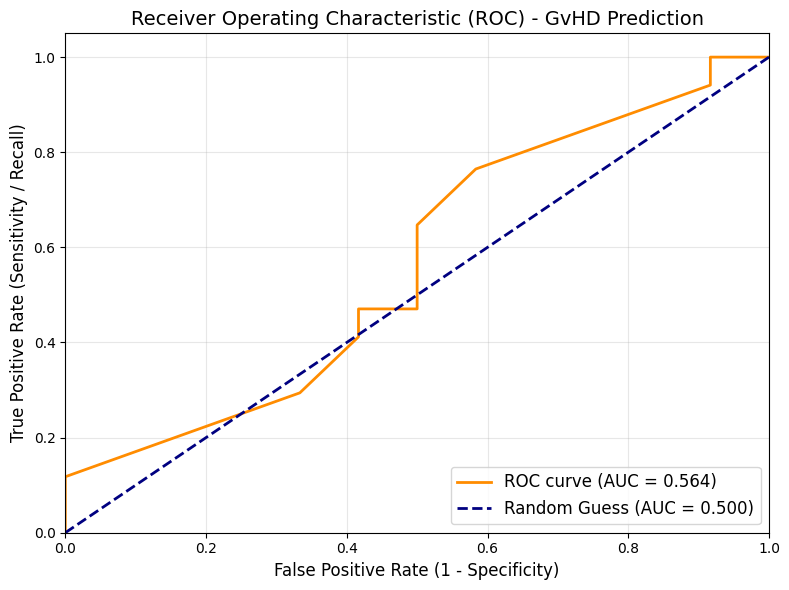

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
best_model = tuner.get_best_models(num_models=1)[0]
# 1. Obtener las probabilidades (ya lo hicimos antes, pero lo repetimos por claridad)
y_pred_probs = best_model.predict(X_val)

# 2. Calcular la tasa de falsos positivos (FPR) y verdaderos positivos (TPR)
fpr, tpr, thresholds_roc = roc_curve(y_val, y_pred_probs)

# 3. Calcular el valor exacto del AUC
roc_auc = auc(fpr, tpr)
# Alternativamente, puedes usar roc_auc_score(y_val, y_pred_probs)

print(f"Valor del ROC-AUC: {roc_auc:.4f}")

# 4. Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

# Configuraciones estéticas del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) - GvHD Prediction', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Mostrar o guardar
plt.show()
# plt.savefig("roc_curve_gvhd.png", dpi=300) # Descomenta para guardar para tu paper

#Retrieve best hyperparameters and estimate BEST_EPOCH on train/val

In [ ]:
# ======== Best tuner hyperparameters ========
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters found:")
for name in best_hp.values:
    print(f"  {name}: {best_hp.get(name)}")
# ======== Evaluation of the tuner BEST MODEL on train and val ========

# Model already trained that the tuner considers best
best_model_tuner = tuner.get_best_models(1)[0]

def eval_split(name, X, y, model, threshold=0.5):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n==== {name.upper()} ====")
    print(f"Umbral = {threshold:.2f}")
    print("Classification report:")
    print(classification_report(y, y_pred, digits=3))

    cm = confusion_matrix(y, y_pred)
    print("Confusion matrix (rows = true, cols = predicted):")
    print(cm)

# X_train and X_val are already the matrices transformed by pre_tune
eval_split("train", X_train, y_train, best_model_tuner, threshold=0.5)
eval_split("val",   X_val,   y_val,   best_model_tuner, threshold=0.5)

# ======== Entrenar de nuevo en train/val para medir BEST_EPOCH ========
val_f1_tmp = ValF1Callback(
    val_data=(X_val, y_val),
    average='binary',
    threshold=0.5,
    save_best_path=None,
    verbose=False
)

es_tmp = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

rlr_tmp = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

tmp_model = build_model(best_hp)

history = tmp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[val_f1_tmp, es_tmp, rlr_tmp],
    verbose=0
)

hist = history.history
print("Keys in history:", list(hist.keys()))

import numpy as np

if "val_f1" in hist:
    best_epoch_f1 = int(np.argmax(hist["val_f1"])) + 1
    print(f"Best epoch according to val_f1: {best_epoch_f1}")
else:
    best_epoch_f1 = None
    print("Could not find 'val_f1' en history.")

if "val_loss" in hist:
    best_epoch_loss = int(np.argmin(hist["val_loss"])) + 1
    print(f"Best epoch according to val_loss: {best_epoch_loss}")
else:
    best_epoch_loss = None

# Usamos val_f1 como criterio principal
if best_epoch_f1 is not None:
    BEST_EPOCH = best_epoch_f1
elif best_epoch_loss is not None:
    BEST_EPOCH = best_epoch_loss
else:
    BEST_EPOCH = EPOCHS

print(f"We'll use BEST_EPOCH = {BEST_EPOCH}")


Best hyperparameters found:
  n_pre_layers: 1
  pre_units: 8
  l2: 0.0
  dropout_pre: 0.0
  encoder_units: 16
  dropout_enc: 0.0
  lr: 0.0005


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



==== TRAIN ====
Umbral = 0.50
Classification report:
              precision    recall  f1-score   support

           0      0.500     0.032     0.060        63
           1      0.604     0.979     0.747        95

    accuracy                          0.601       158
   macro avg      0.552     0.505     0.403       158
weighted avg      0.562     0.601     0.473       158

Confusion matrix (rows = true, cols = predicted):
[[ 2 61]
 [ 2 93]]

==== VAL ====
Umbral = 0.50
Classification report:
              precision    recall  f1-score   support

           0      1.000     0.083     0.154        12
           1      0.607     1.000     0.756        17

    accuracy                          0.621        29
   macro avg      0.804     0.542     0.455        29
weighted avg      0.770     0.621     0.507        29

Confusion matrix (rows = true, cols = predicted):
[[ 1 11]
 [ 0 17]]



Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 35: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 25.
Keys in history: ['auc', 'loss', 'val_auc', 'val_loss', 'val_f1', 'learning_rate']
Best epoch according to val_f1: 10
Best epoch according to val_loss: 25
We'll use BEST_EPOCH = 10


# Retrain the base model from scratch on the FULL dataset with BEST_EPOCH

In [ ]:
# ======== Build the full dataset (X_full, y_full) ========
X_full_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_full = pd.concat([y_train, y_val], axis=0).values  # array

print("Shape X_full_raw:", X_full_raw.shape)
print("Shape y_full    :", y_full.shape)

# ======== Final preprocessor (fit on the FULL dataset) ========
pre_full = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         cat_cols),

    ]
)

X_full = pre_full.fit_transform(X_full_raw)
print("Shape X_full procesado:", X_full.shape)

# ======== Base model definitivo con best_hp ========
base_model = build_model(best_hp)
base_model.summary()

history_full = base_model.fit(
    X_full, y_full,
    epochs=BEST_EPOCH,
    batch_size=BATCH_SIZE,
    verbose=0
)

print(f"Base model training completed ({BEST_EPOCH} epochs on the full dataset).")


Shape X_full_raw: (187, 4)
Shape y_full    : (187,)
Shape X_full procesado: (187, 9)


Model: "base_gvhd_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_dense_1 (Dense)             │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gvhd_head (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

Base model training completed (10 epochs on the full dataset).


#Save base model and preprocessor

In [ ]:
# ======== Save artifacts ========
base_model.save(MODEL_BASE_FULL_PATH, overwrite=True)
joblib.dump(pre_full, PREPROCESSOR_PATH)

print("Base model (full data) saved to:", MODEL_BASE_FULL_PATH)
print("Preprocessor saved to:", PREPROCESSOR_PATH)

# ======== Save META ========
# armamos un diccionario con la info importante
meta = {
    "target": TARGET,
    "columns_used": cols,
    "cat_cols": cat_cols,
    #"num_cols": num_cols,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "best_epoch": int(BEST_EPOCH),
    "best_hyperparameters": {name: best_hp.get(name) for name in best_hp.values},
    "n_train": int(len(y_train)),
    "n_val": int(len(y_val)),
    "n_full": int(len(y_full)),
    "input_dim_after_preprocessing": int(X_full.shape[1]),
    "model_path": MODEL_BASE_FULL_PATH,
    "preprocessor_path": PREPROCESSOR_PATH
}

with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print("Meta saved to:", META_PATH)


Base model (full data) saved to: outputs_nn_base/base_model_full_data.keras
Preprocessor saved to: outputs_nn_base/preprocessor.joblib
Meta saved to: outputs_nn_base/meta.json
